# SEIS-763 Group Project include group member names with an introduction explaining what problem we are solving:
- We are a state program that provides low interest loans to low income family.
- The maximum amount that we are allowed to approve on a loan up to $300,000
- Default rates tend to be high and we have a limited budget, therefore our goal is to maximize the amount allocated to our agency by predicting home values based on a multitude of different predictors in order to best mitigate loss if a home goes into default and maximize purchasing power to help as many families as possible.


# IMPORTANT!!! PRECONDITIONS
- must put the train.csv and test.csv in the top level of your personal Google Drive account.
- These files can be found in our devliverables.   

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1. Data Cleaning/Imputation



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix

In [ ]:
# Load data
file_path_train = '/content/drive/MyDrive/train.csv'
file_path_test = '/content/drive/MyDrive/test.csv'
df = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

In [ ]:
num_rows = df.shape
print(f'number of rows in test dataset: {df_test.shape}')
print(f"Number of rows in the dataset: {num_rows}")
print(df.head())

number of rows in test dataset: (1459, 80)
Number of rows in the dataset: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN   

In [ ]:
# Drop duplicates
df = df.drop_duplicates()
print("After dropping duplicates: The number of rows: ", df.shape)

After dropping duplicates: The number of rows:  (1460, 81)


In [ ]:
# Show initial missing data
total_missing = df.isnull().sum().sum()
total_test_missing = df_test.isnull().sum().sum()
print(f"Total missing values before imputation: {total_missing}")
print(f"Total missing values before imputation: {total_test_missing}")

Total missing values before imputation: 7829
Total missing values before imputation: 7878


### Heat Map of missing values prior to Imputation

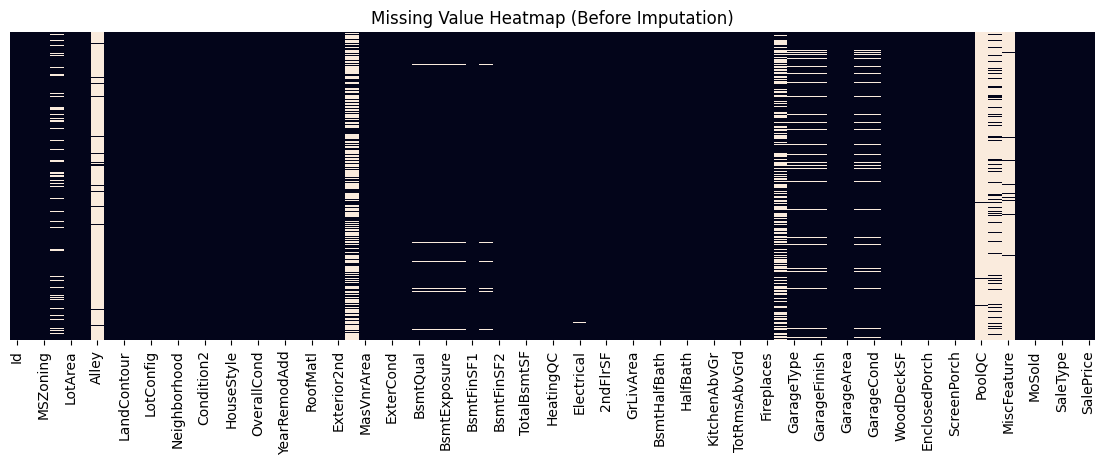

In [ ]:
# 1. Missing Value Heatmap
plt.figure(figsize=(14,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (Before Imputation)')
plt.show()


### Drop any rows that are missing a 'SalePrice' value prior to classification

In [ ]:
df = df.dropna(subset=['SalePrice'])
print(df.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)


In [ ]:
# Separate numeric & categorical

# train
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# test
numeric_cols_test = df_test.select_dtypes(include=['float64', 'int64']).columns
cat_cols_test = df_test.select_dtypes(include=['object']).columns

print(df.shape)
print(df_test.shape)


(1460, 81)
(1459, 80)


In [ ]:
# Ordinal encode categorical data (KNN needs numeric input)
encoder = OrdinalEncoder()
encoded_cats = encoder.fit_transform(df[cat_cols])

# Ordinal encoder for test dataset
encoder_test = OrdinalEncoder()
encoded_cats_test = encoder_test.fit_transform(df_test[cat_cols])


# Combine numeric and encoded categorical
combined = np.hstack((df[numeric_cols], encoded_cats))
combined_test = np.hstack((df_test[numeric_cols_test], encoded_cats_test))

print(df.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)


## Regression VS Classificaiton of the Target (SalePrice)

### Histogram of SalePrice Prior to Trimming Data Set based on the Business Requirements
- Useful when determining the skew of data outliers
- Paticularly useful when applying classification to the numeric target

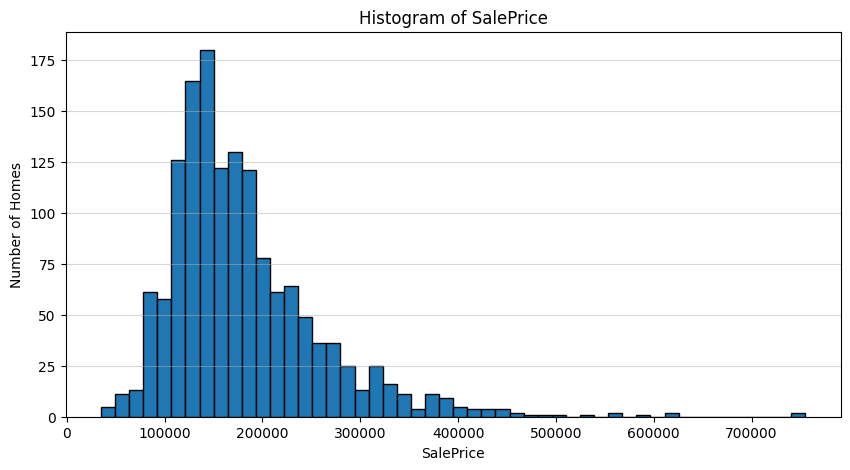

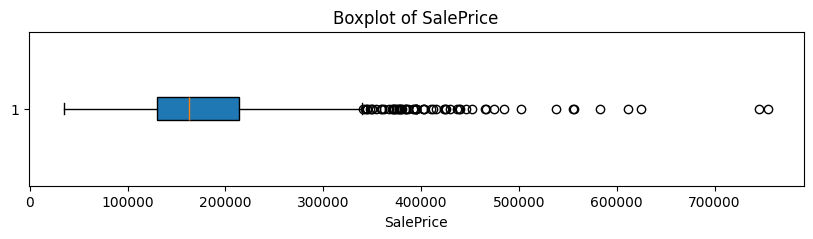

In [ ]:
# Plot a histogram of SalePrice
plt.figure(figsize=(10, 5))
plt.hist(df['SalePrice'], bins=50, edgecolor='black')
plt.title('Histogram of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Number of Homes')
plt.grid(axis='y', alpha=0.5)
plt.show()

# Plot a boxplot of SalePrice
plt.figure(figsize=(10, 2))
plt.boxplot(df['SalePrice'], vert=False, patch_artist=True)
plt.title('Boxplot of SalePrice')
plt.xlabel('SalePrice')
plt.show()


### Log SalePrice
- Useful for shrinking outliers if using regression ans SalePrice as your target

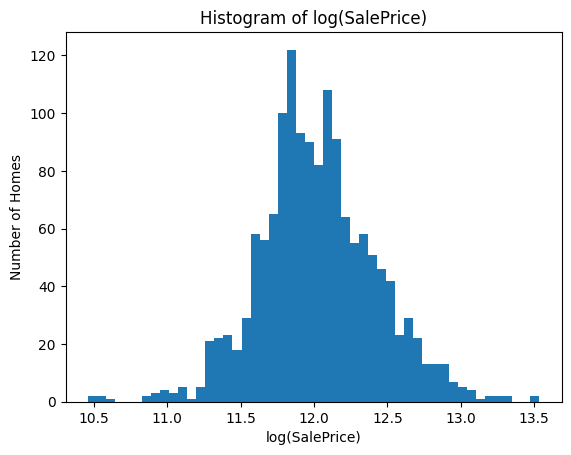

In [ ]:
import numpy as np
plt.hist(np.log1p(df['SalePrice']), bins=50)
plt.title('Histogram of log(SalePrice)')
plt.xlabel('log(SalePrice)')
plt.ylabel('Number of Homes')
plt.show()

### Address Missing Values
- Addpy KNN Imputer

In [ ]:
# Apply KNN imputer
imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(combined)
print(df.shape)
print(df_test.shape)
imputer_test = KNNImputer(n_neighbors=5)
imputed_test = imputer_test.fit_transform(combined_test)

# Reconstruct dataframe
imputed_numeric = pd.DataFrame(imputed[:, :len(numeric_cols)], columns=numeric_cols)
imputed_cats = pd.DataFrame(imputed[:, len(numeric_cols):], columns=cat_cols)

imputed_numeric_test = pd.DataFrame(imputed_test[:, :len(numeric_cols_test)], columns=numeric_cols_test)
imputed_cats_test = pd.DataFrame(imputed_test[:, len(numeric_cols_test):], columns=cat_cols_test)

# Decode categorical back to original labels
decoded_cats = pd.DataFrame(encoder.inverse_transform(imputed_cats), columns=cat_cols)
decoded_cats_test = pd.DataFrame(encoder_test.inverse_transform(imputed_cats_test), columns=cat_cols_test)

# Combine numeric and categorical
df_imputed = pd.concat([imputed_numeric, decoded_cats], axis=1)
df_test = pd.concat([imputed_numeric_test, decoded_cats_test], axis=1)

# Verify
print(f"Total missing values after imputation: {df_imputed.isnull().sum().sum()}")
print(f"Total missing values from test dataset after imputation: {df_test.isnull().sum().sum()}")
print("KNN numeric + categorical imputation completed.")

print(df_imputed.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)
Total missing values after imputation: 0
Total missing values from test dataset after imputation: 0
KNN numeric + categorical imputation completed.
(1460, 81)
(1459, 80)


### Apply Heat Map After Imputing  KNN Imputation

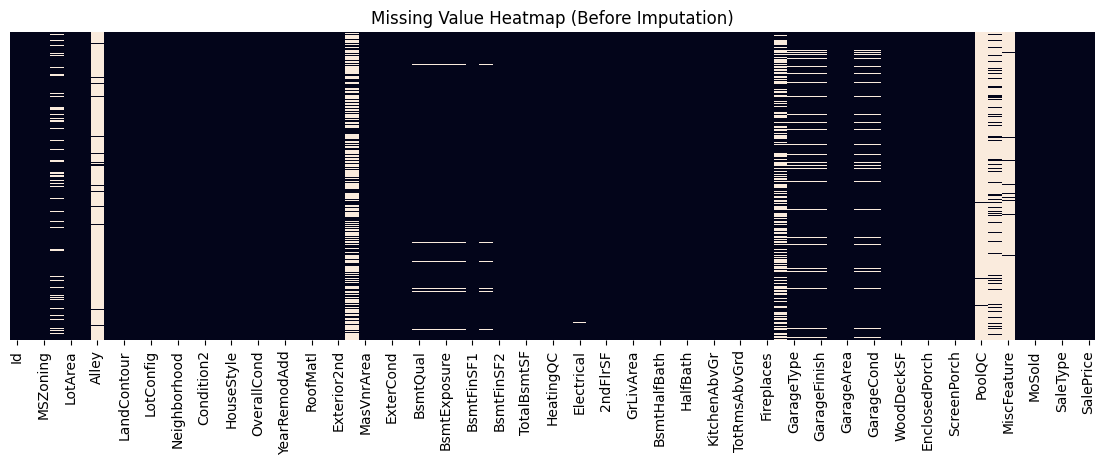

In [ ]:
# Missing Value Heatmap
plt.figure(figsize=(14,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (Before Imputation)')
plt.show()

### Create a Histogram and a Boxplot of the SalePrice using the dataset to determine the price range of our classes.

# Step 4. Remove outliers (IQR, Z-score, etc.) + Step 6. Apply Classification to the target



### Remove Outliers on our Target (SalePrice) Based on Low Interest Government Financing to Low Income Families

In [ ]:
## Previous IQR that was overruled by business rules
# outliers = {}
# q1 = df_imputed['SalePrice'].quantile(0.25)
# q3 = df_imputed['SalePrice'].quantile(0.75)
# iqr = q3 - q1
# lower = q1 - 1.5 * iqr
# upper = q3 + 1.5 * iqr

# # Use 20,000 as a minimum due to logic that this is likely the lowest that a home would sell for.
# lower = 20000

# # Set upper limit to $300,000 due to Organizational Business Rules
# mortgage_upper = np.float64(300000)
# outliers['SalePrice'] = (lower, mortgage_upper)
# print(f'lower: {lower} upper: {mortgage_upper}')
# print(outliers)
# q1 = df_imputed['SalePrice'].quantile(0.25)
# q3 = df_imputed['SalePrice'].quantile(0.75)
# iqr = q3 - q1

# Instead of applying IQR use business constraint of $320k maximum (Applying an IQR puts the upper range slightly above 300k and most data points are clumped together between 100-300k)
lower = 40000  # <<< BUSINESS RULE # No values below 40k exist in the dataset and any house that's priced below 40k would certainly be an outlier.
upper = 320001 # <<< BUSINESS RULE

df_imputed = df_imputed[(df_imputed['SalePrice'] >= lower) & (df_imputed['SalePrice'] <= upper)].copy()

## Use Classification on the SalePrice column (target) over predicting SalePrice Directly we have determined provides the following:

### Risk Management:
- Price bins clearly correlate to risk and affordability, helping loan officers make better lending decisions.
- Predicting a range is easier and more actionable than pinpointing exact home price, especially given limited data (1,500 records).

### Interpretability:
- Price categories are easily explained to non-technical stakeholders (loan officers, regulators, buyers).

### Robustness and Stability
- Predicting precise numeric prices is harder due to high variability and data noise.
- Classification stabilizes predictions into clearly actionable bins.

In [ ]:
bins = np.arange(40000, 320_001, 40_000)
labels = [f'${bins[i]:,.0f}–${bins[i+1]:,.0f}' for i in range(len(bins)-1)]
df_imputed['PriceCategory'] = pd.cut(df_imputed['SalePrice'], bins=bins, labels=labels, include_lowest=True)

df_imputed = df_imputed[~df_imputed['PriceCategory'].isna()].reset_index(drop=True)

# Display the counts per category after filtering
print(df_imputed['PriceCategory'].value_counts().sort_index())

print(df_imputed.shape)
print(df_test.shape)

PriceCategory
$40,000–$80,000       35
$80,000–$120,000     230
$120,000–$160,000    446
$160,000–$200,000    318
$200,000–$240,000    182
$240,000–$280,000    105
$280,000–$320,000     59
Name: count, dtype: int64
(1375, 82)
(1459, 80)


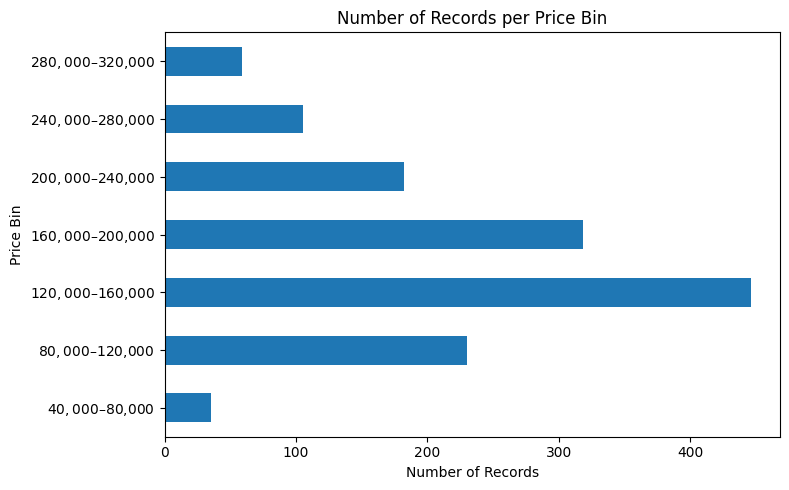

PriceCategory
$40,000–$80,000       35
$80,000–$120,000     230
$120,000–$160,000    446
$160,000–$200,000    318
$200,000–$240,000    182
$240,000–$280,000    105
$280,000–$320,000     59
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
bin_counts = df_imputed['PriceCategory'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bin_counts.plot(kind='barh')  # <-- horizontal bars
plt.ylabel('Price Bin')       # Bin labels on Y axis
plt.xlabel('Number of Records')
plt.title('Number of Records per Price Bin')
plt.tight_layout()
plt.show()
print(df_imputed['PriceCategory'].value_counts().sort_index())

In [ ]:
# Identify categorical columns to encode (excluding PriceCategory)
categorical_cols_to_encode = df_imputed.select_dtypes(include=['object', 'category']).columns.tolist()
if 'PriceCategory' in categorical_cols_to_encode:
    categorical_cols_to_encode.remove('PriceCategory')

categorical_cols_to_encode_test = df_test.select_dtypes(include=['object', 'category']).columns.tolist()
if 'PriceCategory' in categorical_cols_to_encode_test:
    categorical_cols_to_encode_test.remove('PriceCategory')

# Apply one-hot encoding to the selected categorical columns
df_imputed = pd.get_dummies(df_imputed, columns=categorical_cols_to_encode, prefix='PC')
df_test = pd.get_dummies(df_test, columns=categorical_cols_to_encode_test, prefix='PC')

# Quickly check the distribution of the target variable BEFORE one-hot encoding it
print(df_imputed['PriceCategory'].value_counts().sort_index())


print(df_imputed.shape)
print(df_test.shape)

# Columns in df_imputed but not in df_test
missing_in_df_test = set(df_imputed.columns) - set(df_test.columns)
print("Columns in df_imputed but missing in df_test:", missing_in_df_test)


PriceCategory
$40,000–$80,000       35
$80,000–$120,000     230
$120,000–$160,000    446
$160,000–$200,000    318
$200,000–$240,000    182
$240,000–$280,000    105
$280,000–$320,000     59
Name: count, dtype: int64
(1375, 289)
(1459, 270)
Columns in df_imputed but missing in df_test: {'PC_Other', 'PC_Mix', 'PC_NoSeWa', 'PC_Metal', 'SalePrice', 'PC_Roll', 'PC_2.5Fin', 'PC_ClyTile', 'PC_Floor', 'PC_OthW', 'PC_TenC', 'PriceCategory', 'PC_Membran'}


In [ ]:
# Create a copy of the DataFrame to work with for filtering and subsequent steps.
df_filtered = df_imputed.copy()

# Ensure PriceCategory is present for subsequent steps, assuming it was created earlier
if 'PriceCategory' not in df_filtered.columns:
    print("Warning: 'PriceCategory' column not found. Please ensure it was created in a previous step.")

# Check if the dummy columns for PriceCategory exist and revert if necessary
pc_dummy_cols = [col for col in df_filtered.columns if col.startswith('PC_')]
if pc_dummy_cols:
    print("Attempting to revert PriceCategory one-hot encoding if it occurred.")
    pass


print(df_filtered.shape)

print(df_filtered['PriceCategory'].value_counts().sort_index())

Attempting to revert PriceCategory one-hot encoding if it occurred.
(1375, 289)
PriceCategory
$40,000–$80,000       35
$80,000–$120,000     230
$120,000–$160,000    446
$160,000–$200,000    318
$200,000–$240,000    182
$240,000–$280,000    105
$280,000–$320,000     59
Name: count, dtype: int64



### Classifying the SalePrice Colummn: Complete

## Create a SQLite Database to understand the data better
  - Useful for creating visualizations of data within the database
  - Use dataframe after imputation but before standardization

In [ ]:
import sqlite3

conn = sqlite3.connect('homesales.db')
df.to_sql('homes', conn, if_exists='replace', index=False)

1460

### Create Function to run a query and return a result set from our SQLite Database

In [ ]:
import sqlite3
import pandas as pd

def run_sql_query(query, db_path='homesales.db'):
    """
    Executes a SQL query on the given SQLite database and returns a pandas DataFrame.

    Args:
        query (str): The SQL query to run.
        db_path (str): Path to the SQLite database file (default 'homesales.db').

    Returns:
        pd.DataFrame: The result of the query as a DataFrame.
    """
    # Connect, run query, and close connection
    with sqlite3.connect(db_path) as conn:
        result_df = pd.read_sql_query(query, conn)
    return result_df

## Continue cleaning the data:
- Standardize the Data
- One-hot-Encode the Categorical Predictors

### One-hot encode other categorical variables, but NOT PriceCategory as it's the target

In [ ]:
numerical_columns = df_filtered.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_columns)

numerical_columns_test = df_test.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_columns_test)

import scipy.stats as stats

df_filtered[numerical_columns] = df_filtered[numerical_columns].apply(stats.zscore)
df_test[numerical_columns_test] = df_test[numerical_columns_test].apply(stats.zscore)

other_columns = df_filtered.select_dtypes(include=['object']).columns.tolist()
print(other_columns)

other_columns_test = df_test.select_dtypes(include=['object']).columns.tolist()
print(other_columns_test)

df_filtered = pd.get_dummies(df_filtered, columns=other_columns, drop_first=True)
print(df_filtered.shape)
print(df_filtered.head())

df_test = pd.get_dummies(df_test, columns=other_columns_test, drop_first=True)
print(df_test.shape)
print(df_test.head())

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'Mis

### Step 2. Correlation Analysis + Step 3. Continue with Scaling/Standardization


### Splitting Predictors, Dropping Highly Correlated Columns, and Standardizing

In [ ]:
df_cleaned = df_filtered.copy()

# Separate features (X) and target (y)
X = df_cleaned.drop(columns=['SalePrice', 'PriceCategory', 'Id'], errors='ignore') # Drop SalePrice, PriceCategory and Id
y = df_cleaned["PriceCategory"]

print("Shape BEFORE one-hot encoding and standardization:", X.shape)
print(y.value_counts().sort_index())
print(df_test.shape)
print(df_test.head())

Shape BEFORE one-hot encoding and standardization: (1375, 286)
PriceCategory
$40,000–$80,000       35
$80,000–$120,000     230
$120,000–$160,000    446
$160,000–$200,000    318
$200,000–$240,000    182
$240,000–$280,000    105
$280,000–$320,000     59
Name: count, dtype: int64
(1459, 270)
         Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
0 -1.730864   -0.874711     0.484276  0.363929    -0.751101     0.400766   
1 -1.728490   -0.874711     0.530159  0.897861    -0.054877     0.400766   
2 -1.726115    0.061351     0.208979  0.809646    -0.751101    -0.497418   
3 -1.723741    0.061351     0.392510  0.032064    -0.054877     0.400766   
4 -1.721367    1.465443    -1.213388 -0.971808     1.337571    -0.497418   

   YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  PC_ConLw  PC_New  \
0  -0.340945     -1.072885   -0.569632    0.063936  ...     False   False   
1  -0.439695     -1.214908    0.040544    1.063714  ...     False   False   
2   0.844059      0.67

In [ ]:
# # Identify numerical and categorical columns for processing
# numerical_cols = X.select_dtypes(include=np.number).columns
# categorical_cols = X.select_dtypes(exclude=np.number).columns


# # Apply one-hot encoding to categorical features
# X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
# Compute correlation matrix AFTER one-hot encoding
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop based on high correlation (threshold > 0.85)
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

In [ ]:
# Drop the highly correlated columns
X_reduced = X.drop(columns=to_drop)

print("Shape AFTER dropping highly correlated columns:", X_reduced.shape)

# Preview cleaned predictors before standardization
print("\nPreview of cleaned predictors (before standardization):")
print(X_reduced.head())

Shape AFTER dropping highly correlated columns: (1375, 163)

Preview of cleaned predictors (before standardization):
   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
0    0.056981    -0.207733 -0.199625     0.838599    -0.536661   1.109121   
1   -0.872975     0.447529 -0.062230     0.032817     2.153165   0.205661   
2    0.056981    -0.076681  0.134901     0.838599    -0.536661   1.042198   
3    0.289470    -0.426154 -0.068204     0.838599    -0.536661  -1.835491   
4    0.056981     0.622266  0.494516     1.644380    -0.536661   1.008737   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  PC_ConLI  PC_ConLw  \
0      0.925549    0.693332    0.695715   -0.294772  ...     False     False   
1     -0.382993   -0.564563    1.338617   -0.294772  ...     False     False   
2      0.877084    0.475126    0.175720   -0.294772  ...     False     False   
3     -0.673780   -0.564563   -0.462455   -0.294772  ...     False     False   
4      0.780155    1

In [ ]:
print(X_reduced.isnull().sum().sum())  # Should be 0
print(df_test.isnull().sum().sum())  # Should be 0

0
0


### Standardize the numerical columns

In [ ]:
# Identify numerical columns that are still present in X_reduced
numerical_cols_in_reduced = X_reduced.select_dtypes(include=np.number).columns

# Use a ColumnTransformer to apply StandardScaler only to these numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_in_reduced)
    ],
    remainder='passthrough' # Keep other columns (one-hot encoded) as they are
)

X_scaled = preprocessor.fit_transform(X_reduced)

In [ ]:
numerical_cols_in_reduced_test = df_test.select_dtypes(include=np.number).columns

# Use a ColumnTransformer to apply StandardScaler only to these numerical columns
preprocessor_test = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_in_reduced_test)
    ],
    remainder='passthrough' # Keep other columns (one-hot encoded) as they are
)

test_scaled = preprocessor.fit_transform(df_test)

In [ ]:
# Identify numerical and categorical columns for processing
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(exclude=np.number).columns

# original one-hot encoded column names from X_reduced that were not numerical.
original_numerical_cols_in_reduced = [col for col in numerical_cols if col in X_reduced.columns]
original_other_cols_in_reduced = [col for col in X_reduced.columns if col not in numerical_cols]
X_scaled_df = pd.DataFrame(X_scaled, columns=list(numerical_cols_in_reduced) + original_other_cols_in_reduced)

# Confirm means and stds for numerical columns after standardizatio
standard_deviation = X_scaled_df[numerical_cols_in_reduced].std()
print("\nStds after standardization (should be ~1) for numerical columns:", standard_deviation.head())

mean = X_scaled_df[numerical_cols_in_reduced].mean()
print("\nMeans after standardization (should be ~0) for numerical columns:", mean.head())

print("\nFinal cleaned and standardized predictors shape:", X_scaled_df.shape)


Stds after standardization (should be ~1) for numerical columns: MSSubClass     1.000364
LotFrontage    1.000364
LotArea        1.000364
OverallQual    1.000364
OverallCond    1.000364
dtype: float64

Means after standardization (should be ~0) for numerical columns: MSSubClass     5.038394e-17
LotFrontage    2.067033e-17
LotArea       -2.583792e-18
OverallQual   -4.521636e-17
OverallCond   -3.617308e-17
dtype: float64

Final cleaned and standardized predictors shape: (1375, 163)


In [ ]:
# Identify numerical and categorical columns for processing
numerical_cols_test = df_test.select_dtypes(include=np.number).columns
categorical_cols_test = df_test.select_dtypes(exclude=np.number).columns

# original one-hot encoded column names from X_reduced that were not numerical.
original_numerical_cols_in_reduced_test = [col for col in numerical_cols_test if col in df_test.columns]
original_other_cols_in_reduced_test = [col for col in df_test.columns if col not in numerical_cols_test]
X_scaled_df_test = pd.DataFrame(test_scaled, columns=list(numerical_cols_in_reduced_test) + original_other_cols_in_reduced_test)


# Confirm means and stds for numerical columns after standardization
print("\nMeans after standardization (should be ~0) for numerical columns:")
print(X_scaled_df_test[numerical_cols_in_reduced_test].mean().head())

print("\nStds after standardization (should be ~1) for numerical columns:")
print(X_scaled_df_test[numerical_cols_in_reduced_test].std().head())



Means after standardization (should be ~0) for numerical columns:
Id             0.0
MSSubClass    -0.0
LotFrontage   -0.0
LotArea       -0.0
OverallQual    0.0
dtype: object

Stds after standardization (should be ~1) for numerical columns:
Id             1.000343
MSSubClass     1.000343
LotFrontage    1.000343
LotArea        1.000343
OverallQual    1.000343
dtype: object


### Summary of Results:

- Shape Before: (1399 rows, 189 columns)
- Initial dataset after one-hot encoding and outlier removal.

- Computed Correlation Matrix:
 -  Measured pairwise relationships between predictors to detect multicollinearity.

- Columns Dropped Due to High Correlation: 13
 - Removed predictors with >0.85 correlation to avoid redundancy and improve model interpretability.

- Shape After Dropping Columns: (1399 rows, 176 columns)
 - Confirmed correct reduction in features.

- Standardized All Predictors:
 - Scaled features to mean ≈0 and standard deviation ≈1 to ensure comparability and support model convergence.

- Means After Scaling: ~0
 - Verified successful centering of each feature.

- Standard Deviations After Scaling: ~1
 - Verified correct scaling to unit variance.

### Outcome:
 - This cleaned and standardized dataset (X_scaled_df) is ready for regression modeling (Lasso, SVM, etc.) with reduced multicollinearity, balanced scales, and clear feature structure.

## Feature Selection Using:
 - Lasso
 - Random Forest
 - Original Plan was to use three methods for feature selection, but RFE turned out to not be ideal due to time constraints.  Finding a replacement and refining the model to take any feature that is included in at least two of the three methods would be ideal.
  - Another feature selection will be implemented in RFE's place to help conduct better feature selection

#### Lasso (Initial Screening)

In [ ]:
 #Step 1: Verify X_scaled_df and y
print(f'Trainning set: {X_scaled_df.shape} {y.shape}')

print(f'\n\nTest scalled: {X_scaled_df_test.shape})')

Trainning set: (1375, 163) (1375,)


Test scalled: (1459, 270))


In [ ]:
print("Class distribution in y:")
print(y.value_counts())

Class distribution in y:
PriceCategory
$120,000–$160,000    446
$160,000–$200,000    318
$80,000–$120,000     230
$200,000–$240,000    182
$240,000–$280,000    105
$280,000–$320,000     59
$40,000–$80,000       35
Name: count, dtype: int64


In [ ]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Verify X_scaled_df and y
print(X_scaled_df.shape, y.shape)

# Check for NaNs in X_scaled_df before fitting Lasso
print("Checking for NaNs in X_scaled_df before Lasso:")
print(X_scaled_df.isnull().sum().sum())
if X_scaled_df.isnull().sum().sum() > 0:
    print("NaN values found in X_scaled_df. Investigating the source of NaNs.")

# Remove rows with NaN in the target variable y and reset index for alignment
nan_in_y = y.isnull()
if nan_in_y.sum() > 0:
    print(f"Removing {nan_in_y.sum()} rows with NaN values in the target variable y.")
    # Reset index of y to align with X_scaled_df's integer index
    y_reset_index = y.reset_index(drop=True)
    # Filter both X_scaled_df and y using the boolean index from the reset y
    X_scaled_df = X_scaled_df[~nan_in_y.reset_index(drop=True)]
    y = y_reset_index[~nan_in_y.reset_index(drop=True)]
    print(f"Shapes after removing NaNs in y: X_scaled_df: {X_scaled_df.shape}, y: {y.shape}")


# Lasso Feature Selection (Logistic Regression with L1 regularization)
# Using the cleaned and standardized data X_scaled_df
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=10000, random_state=42) # Increased max_iter
lasso.fit(X_scaled_df, y)

lasso_model = SelectFromModel(lasso, prefit=True)
lasso_features = X_scaled_df.columns[lasso_model.get_support()]

(1375, 163) (1375,)
Checking for NaNs in X_scaled_df before Lasso:
0


#### Visualization: Coeficients from Lasso
- 49 predictors with non-zero coeficients identified

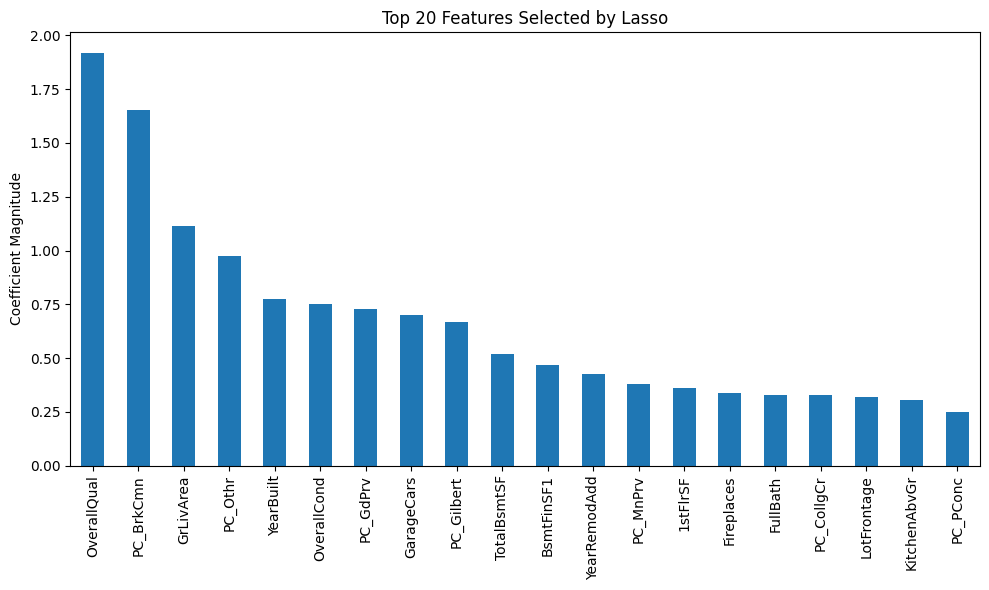

Total number of non-zero predictors: 50


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize Lasso coefficients
coef_abs = np.abs(lasso.coef_).max(axis=0)
lasso_coef_df = pd.Series(coef_abs, index=X_scaled_df.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
lasso_coef_df.plot(kind='bar')
plt.title('Top 20 Features Selected by Lasso')
plt.ylabel('Coefficient Magnitude')
plt.tight_layout()
plt.show()

num_nonzero = (coef_abs > 0).sum()
print(f"Total number of non-zero predictors: {num_nonzero}")


#### Important features and impact on value based on Lasso:
- Bkrchn_True: Categorical feature value for MasVnrType (Masonry veneer type)
 - Potential values
  - None
  - Common brick veneer
  - Stone veneer on exterior
  - Just siding or other material

#### Show the frequency of different types of masonary veneer within the dataset to determine to determine sample size.  

  MasVnrType  count
0       None    872
1    BrkFace    445
2      Stone    128
3     BrkCmn     15


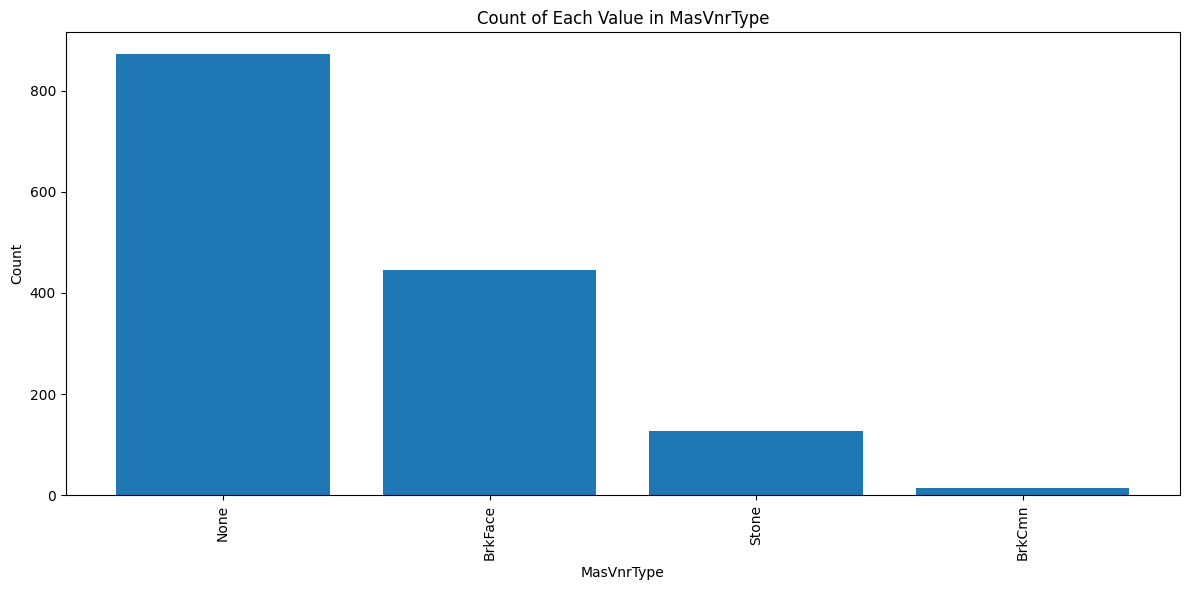

In [ ]:
# Set the column and table you want to analyze
column_name = 'MasVnrType'
table_name = 'homes'

query = f"""
SELECT {column_name}, COUNT(*) AS count
FROM {table_name}
GROUP BY {column_name}
ORDER BY count DESC
"""

df_counts = run_sql_query(query)
print(df_counts)

# Create bar chart visualization of masonary veneer type
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
# Explicitly convert to string type for plotting compatibility
plt.bar(df_counts[column_name].astype(str), df_counts['count'])
plt.xlabel(column_name)
plt.ylabel('Count')
plt.title(f'Count of Each Value in {column_name}')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### The image above shows one of the pitfalls of using only one method for feature selection in this case using Lasso (l1 logistic regression)
- BrkCmn is listed as the second most influencial factor on the target, yet the sample size is 12 out of close to 1500 rows.  This feature shouldn't be included in the final model and proves that the data should be filtered using more than one method
- Originally we applyed Lasso, RFE, and Random Forest to the dataset.  With over 160 features afte one-hot encoding and selected features that appeared in two of the three.  

#### RFE (Further Refinement) REMOVED!!!
- Removed due to it not being an ideal feature selection tool for datasets with a high number of features
- Typically ideal for datasets with less than 100 features

In [ ]:
## RFE code that was removed

# logreg = LogisticRegression(max_iter=10000, random_state=42) # Increased max_iter
# rfe = RFE(estimator=logreg, n_features_to_select=20)
# rfe.fit(X_scaled_df, y)

# rfe_features = X_scaled_df.columns[rfe.get_support()]

#### Visualization: RFE Selected Features REMOVED!!!

In [ ]:
# # Visualize RFE rankings
# rfe_ranking_df = pd.Series(rfe.ranking_, index=X_scaled_df.columns).sort_values().head(20)

# plt.figure(figsize=(10, 6))
# rfe_ranking_df.plot(kind='bar')
# plt.title('Top 20 Features by RFE Ranking (lower is better)')
# plt.ylabel('Ranking')
# plt.tight_layout()
# plt.show()

#### Further Refinement using Random Forest

#### Random Forest Feature Selection

In [ ]:
# find features that have al least a .01 importance in determining the target.  This number can be tweaked to improve metrics and better improve the fit.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled_df, y)

rf_importances = pd.Series(rf.feature_importances_, index=X_scaled_df.columns).sort_values(ascending=False).head(40)

#### Visualization: Feature importance using Random Forest

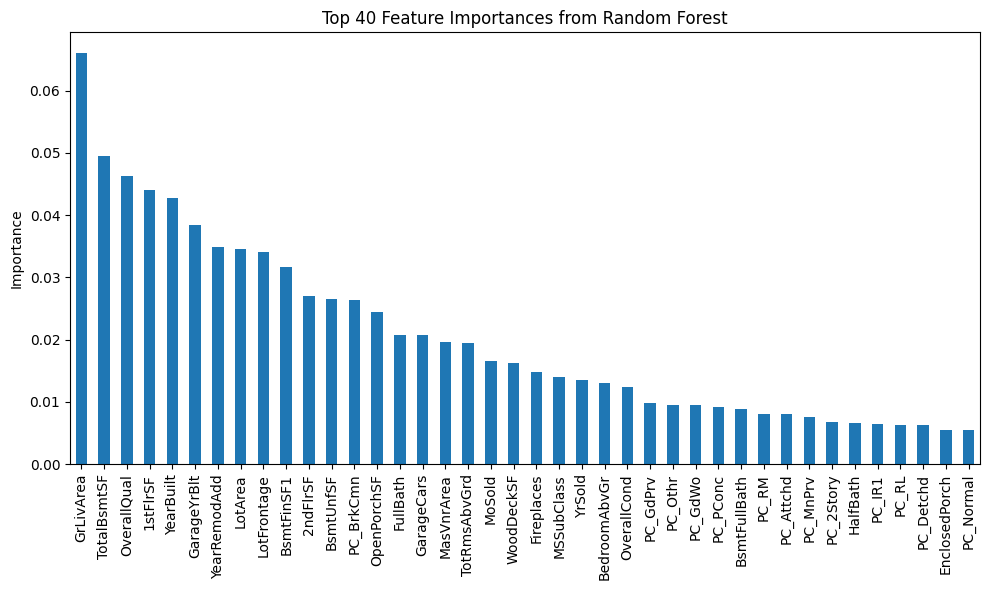

In [ ]:
plt.figure(figsize=(10, 6))
rf_importances.plot(kind='bar')
plt.title('Top 40 Feature Importances from Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

#### Combine feature selection results from Lasso and Random Forest



In [ ]:
# Combine features from Lasso and Random Forest and include all features from both to decline some of the pitfalls that are related to either Lasso or Random Forest if used for feature selection individually.
combined_features = pd.concat([pd.Series(lasso_features), pd.Series(rf_importances.index)]).value_counts()

# Select features identified by at least two methods
final_features = combined_features[combined_features >= 2].index.tolist()

print(f'Total combined features selected: {len(final_features)}')
print('Final selected features:', final_features)

# Convert the Series to DataFrame for Plotly
combined_features_df = combined_features.reset_index()
combined_features_df.columns = ['Feature', 'Frequency']
combined_features_df = combined_features_df.sort_values(by='Frequency', ascending=True)

Total combined features selected: 38
Final selected features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', 'BedroomAbvGr', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'GarageYrBlt', 'Fireplaces', 'TotRmsAbvGrd', 'PC_Othr', 'PC_Normal', 'PC_GdPrv', 'GarageCars', 'OpenPorchSF', 'WoodDeckSF', 'EnclosedPorch', 'PC_RM', 'YrSold', 'PC_RL', 'MoSold', 'PC_MnPrv', 'PC_BrkCmn', 'PC_PConc', 'PC_Attchd', 'PC_IR1', 'PC_GdWo', 'PC_Detchd']


#### Visualization: Feature Selection with Combined Results

In [ ]:
import plotly.express as px

# Plot using Plotly
fig = px.bar(
    combined_features_df,
    x='Frequency',
    y='Feature',
    orientation='h',
    title='Frequency of Features Selected by Lasso, RFE, and Random Forest',
    height=1600,  # Increase height for vertical scroll space
    width=900
)

fig.update_layout(
    yaxis=dict(
        tickfont=dict(size=10),
    ),
    xaxis=dict(title='Selection Frequency'),
    margin=dict(l=200, r=20, t=50, b=20)
)

fig.show()

#### The above features that only show up in one of the two feature evaluation tools should be further studied to determine if including them in the model is useful.  

In [ ]:
print(f"Total features selected by BOTH Lasso and Random Forest: {len(combined_features_df)}")
print("Features in both methods:\n", sorted(combined_features_df))


Total features selected by BOTH Lasso and Random Forest: 52
Features in both methods:
 ['Feature', 'Frequency']


#### Refine DataFrame with Feature Selection
- 52 features identified after combining features from both Lasso and Random Forest
- Feature selection should be tweaked to find best features to include in our model, but this is a good start.

In [ ]:
# Step 3: Refine dataframe to include only selected features for SVM RBF
X_final = X_scaled_df[final_features]

PCA or t-SNE Scatter Plot (Not being Used!!!)
- Potentially apply this to the data set during the next sprint.  
- Apply dimensionality reduction on the chosen features and is colored by PriceCategory (target)

Number of features after PCA: 2


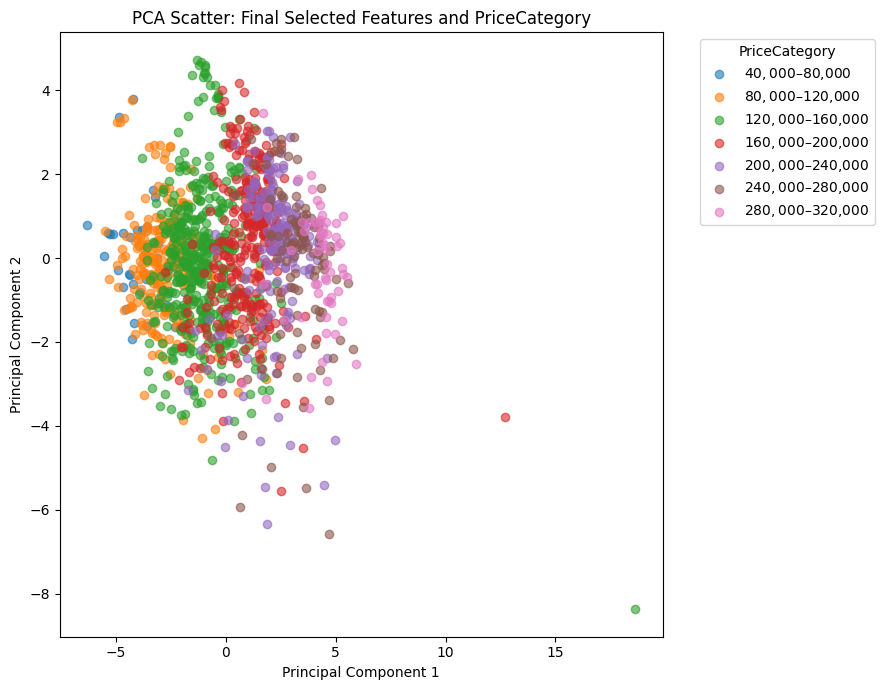

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final)
print("Number of features after PCA:", X_pca.shape[1])

# Use ordered categories for the legend
categories = list(labels)  # or sorted(y.unique(), key=lambda c: labels.index(c))

plt.figure(figsize=(9, 7))
for cat in categories:
    mask = (y == cat)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=str(cat), alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter: Final Selected Features and PriceCategory')
plt.legend(title='PriceCategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Visualization after applying PCA shows that that the total home values are all very closely scattered.  
- This makes classification difficult especially for values that are close to the border of one class or another
 - In the next sprint the edge cases will need to be further analyzed to reduce missclassification of these values

## Train Model Using SVM and RBF:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Step 7 Applying SVM RBF
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

print("Step 7 complete: SVM with RBF kernel has been trained.\n")

y_pred = svm_rbf.predict(X_test)
print("Predictions on validation set:\n\n", y_pred[:10])  # Shows first 10 predictions

print("\nClasses recognized by the model:\n\n", svm_rbf.classes_)

Step 7 complete: SVM with RBF kernel has been trained.

Predictions on validation set:

 ['$160,000–$200,000' '$160,000–$200,000' '$160,000–$200,000'
 '$120,000–$160,000' '$240,000–$280,000' '$120,000–$160,000'
 '$120,000–$160,000' '$120,000–$160,000' '$200,000–$240,000'
 '$40,000–$80,000']

Classes recognized by the model:

 ['$120,000–$160,000' '$160,000–$200,000' '$200,000–$240,000'
 '$240,000–$280,000' '$280,000–$320,000' '$40,000–$80,000'
 '$80,000–$120,000']


### After Applying SVM RBF Apply Permutation Importance to the model to the model to reduce noise and complexity by removing unimportant or even counter productive features
- This should help remove some of the features that were included in either Lasso or Random Forest that are were incorrectly identified as important features.
- Permutation Importance is model-agnostic

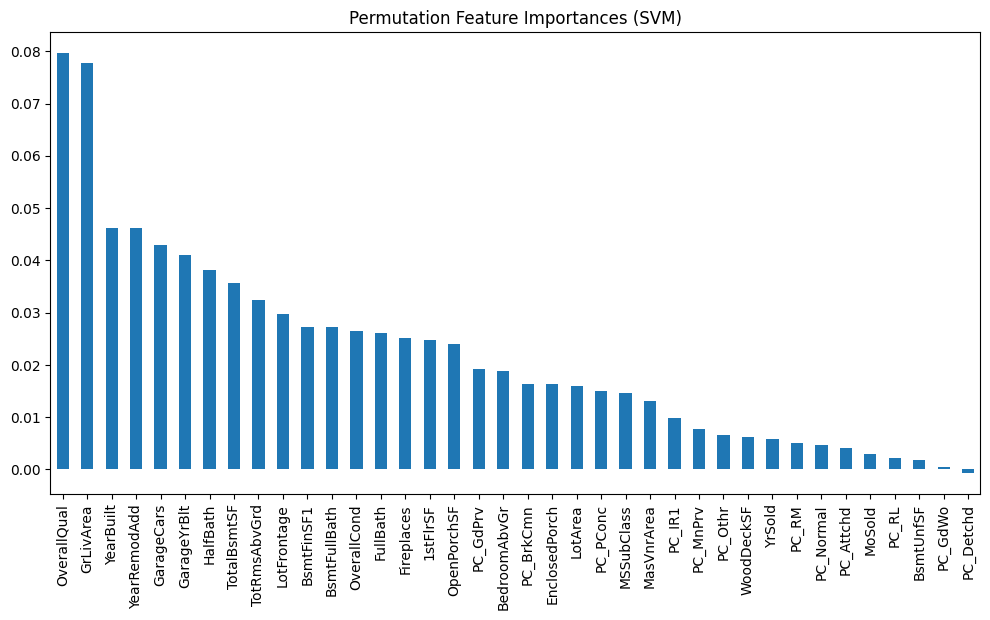

Features to remove (<=0 importance): ['PC_Detchd']

 Model metrics after applying feature selection tools:

                    precision    recall  f1-score   support

$120,000–$160,000       0.77      0.87      0.81        89
$160,000–$200,000       0.66      0.73      0.70        64
$200,000–$240,000       0.59      0.56      0.57        36
$240,000–$280,000       0.50      0.38      0.43        21
$280,000–$320,000       0.83      0.42      0.56        12
  $40,000–$80,000       1.00      0.29      0.44         7
 $80,000–$120,000       0.85      0.85      0.85        46

         accuracy                           0.72       275
        macro avg       0.74      0.58      0.62       275
     weighted avg       0.72      0.72      0.71       275



In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(svm_rbf, X_test, y_test, n_repeats=10, random_state=42)
importances = pd.Series(result.importances_mean, index=X_test.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12,6)) # Set figure size before plotting
importances.plot.bar(title='Permutation Feature Importances (SVM)')
plt.show()

# Features to remove: those with importance <= 0
to_drop = importances[importances <= 0].index.tolist()
print("Features to remove (<=0 importance):", to_drop)

# Remove unimportant features from your train and test data
X_train_reduced = X_train.drop(columns=to_drop, errors='ignore')
X_test_reduced = X_test.drop(columns=to_drop, errors='ignore')

final_model = SVC(kernel='rbf', random_state=42)
final_model.fit(X_train_reduced, y_train)
y_pred_reduced = final_model.predict(X_test_reduced)
final_model.fit(X_train_reduced, y_train)
y_pred = final_model.predict(X_test_reduced)

from sklearn.metrics import classification_report
print(f'\n Model metrics after applying feature selection tools:\n\n {classification_report(y_test, y_pred)}')


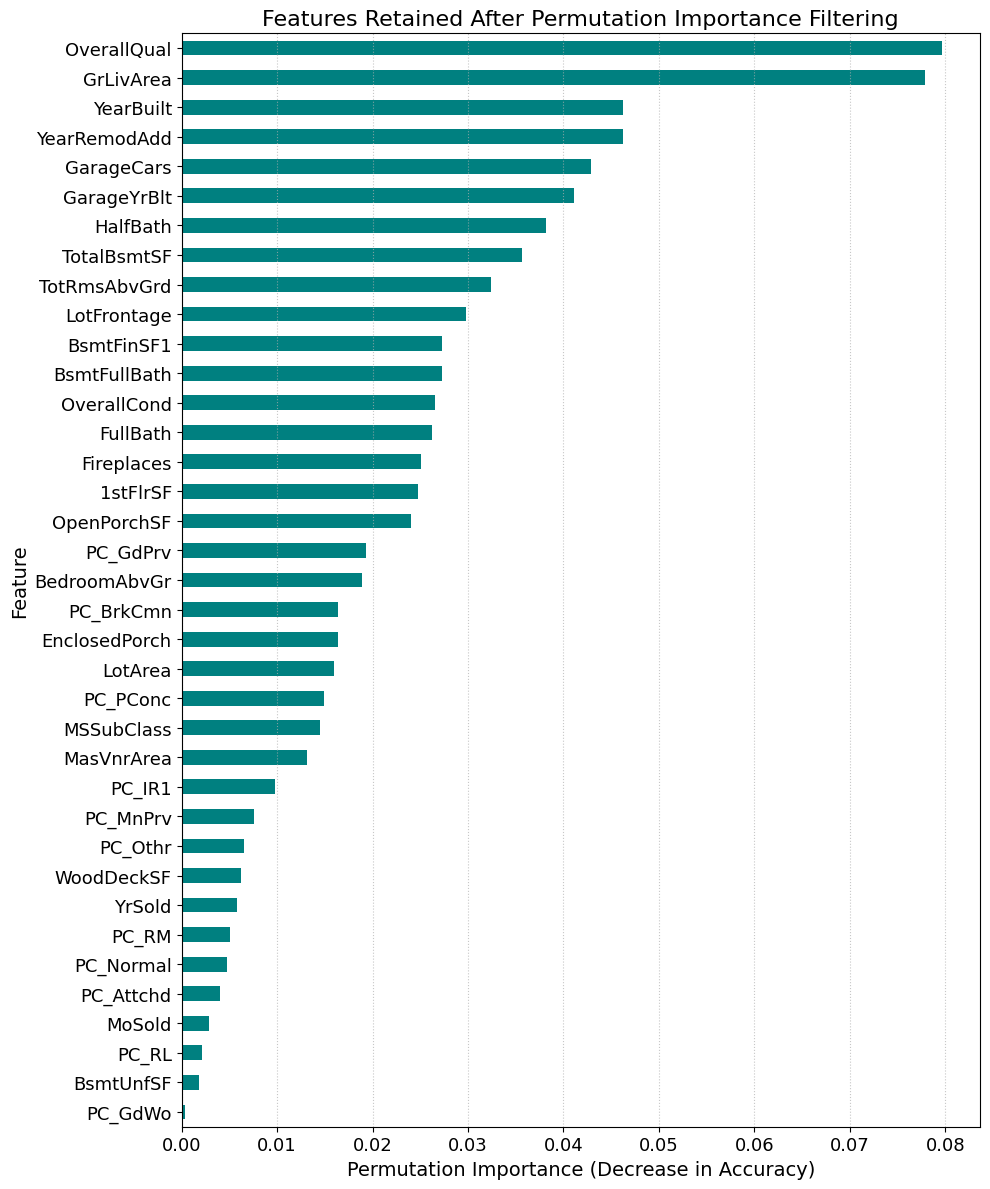

In [ ]:
import matplotlib.pyplot as plt

kept = importances[importances > 0].index.tolist()

# Increase figure height and font size for y-axis labels
importances[kept].sort_values().plot(
    kind='barh',
    figsize=(10, 12),   # Taller plot for more rows
    color='teal'
)
plt.title('Features Retained After Permutation Importance Filtering', fontsize=16)
plt.xlabel('Permutation Importance (Decrease in Accuracy)', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total features left after eliminating the features that have a Permutation Importance value <= 0
- Visualization above is sorted descending from most important to least important feature included in the retrained model.
- Code block below shows number of features retained and a list of the features

In [ ]:
print("Number of features retained:", len(kept))
print("\nFeatures retained:\n\n", kept)

Number of features retained: 37

Features retained:

 ['OverallQual', 'GrLivArea', 'YearBuilt', 'YearRemodAdd', 'GarageCars', 'GarageYrBlt', 'HalfBath', 'TotalBsmtSF', 'TotRmsAbvGrd', 'LotFrontage', 'BsmtFinSF1', 'BsmtFullBath', 'OverallCond', 'FullBath', 'Fireplaces', '1stFlrSF', 'OpenPorchSF', 'PC_GdPrv', 'BedroomAbvGr', 'PC_BrkCmn', 'EnclosedPorch', 'LotArea', 'PC_PConc', 'MSSubClass', 'MasVnrArea', 'PC_IR1', 'PC_MnPrv', 'PC_Othr', 'WoodDeckSF', 'YrSold', 'PC_RM', 'PC_Normal', 'PC_Attchd', 'MoSold', 'PC_RL', 'BsmtUnfSF', 'PC_GdWo']


In [ ]:
cat_type = pd.CategoricalDtype(categories=labels, ordered=True)
y_test_ord = pd.Series(y_test).astype(cat_type)
y_pred_ord = pd.Series(y_pred).astype(cat_type)

In [ ]:
import pandas as pd

# Convert to string (if not already)
y_test_str = pd.Series(y_test_ord).astype(str)
y_pred_str = pd.Series(y_pred_ord).astype(str)

# Remove NaN or 'nan' entries
mask = (y_test_str != 'nan') & (y_pred_str != 'nan')
y_test_clean = y_test_str[mask]
y_pred_clean = y_pred_str[mask]

In [ ]:
# Get all unique values (in order of appearance in test set)
labels_str = list(pd.Series(y_test_clean).unique())
print("Using these labels for confusion matrix:\n\n", labels_str)

Using these labels for confusion matrix:

 ['$240,000–$280,000', '$120,000–$160,000', '$160,000–$200,000', '$200,000–$240,000', '$40,000–$80,000', '$80,000–$120,000']


In [ ]:
cm = confusion_matrix(y_test_clean, y_pred_clean, labels=labels_str)

### Run expirements to determine best box constraint ('C') and gamma value

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': [0.01, 0.05, 0.1]
}

svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'C': 10, 'gamma': 0.01}


### Use Confusion Matrix to display predictions
- Note that most of the missclassifications are on the border between two different classes.  
- This tells us that in the next sprint well need to address the edge cases

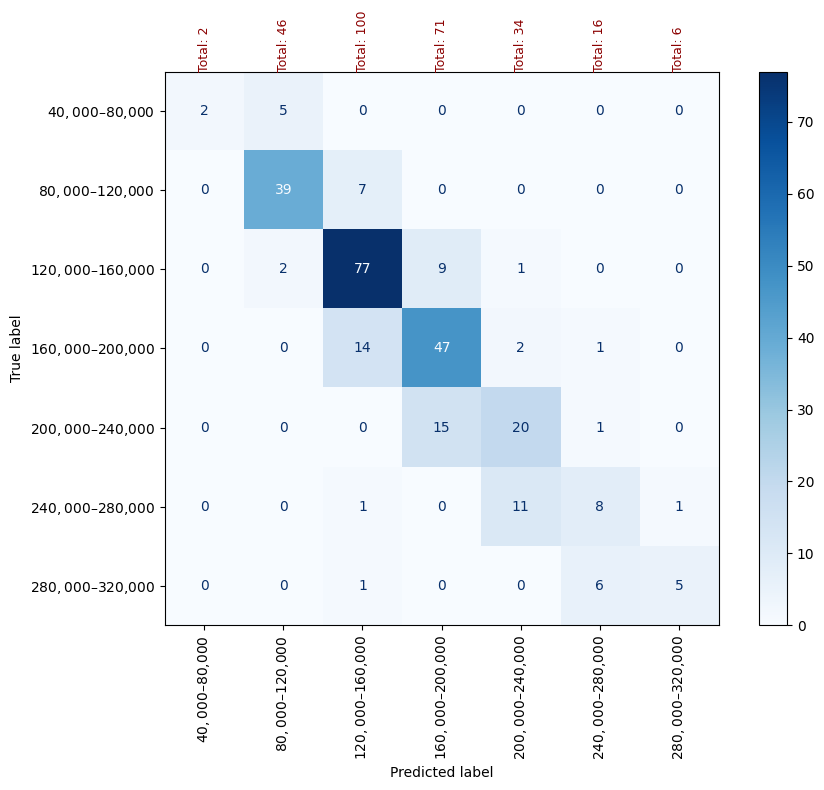

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix with sorted labels
cm = confusion_matrix(y_test_ord, y_pred_ord, labels=labels)

# Calculate total predictions per predicted bin (sum over rows)
totals_pred_bin = np.sum(cm, axis=0)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90, cmap='Blues', ax=ax, colorbar=True)

# Annotate with total predictions above each column
for idx, total in enumerate(totals_pred_bin):
    ax.annotate(f'Total: {total}', (idx, -0.5), ha='center', va='bottom', fontsize=9, color='darkred', rotation=90)

plt.tight_layout()
plt.show()


### Below is a PCA Scatter Plot
- Reduce 36 dimension to 2 dimensions for visualization
- Each poiht represents a single home in the dataset
- Color displayes the home's PriceCategory (sale price bin)
- Notice that there isn't much spread or seperation between most of the value
  - This makes it more difficult to classify especially edge cases.  
- Experiment with boundary margins based on different 'C' and 'gamma' values

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_svm_decision(X, y, C, gamma):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    svm = SVC(kernel='rbf', C=C, gamma=gamma, decision_function_shape='ovr') # Use 'ovr' for consistent output shape
    svm.fit(X_pca, y)

    x_min, x_max = X_pca[:, 0].min()-1, X_pca[:, 0].max()+1
    y_min, y_max = X_pca[:, 1].min()-1, X_pca[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    # Get decision function values for each class
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])

    # Plot decision boundaries for each class
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(svm.classes_):
        # Reshape the decision function values for the current class
        Zi = Z[:, i].reshape(xx.shape)
        plt.contour(xx, yy, Zi, levels=[0], colors=[f'C{i}'], linewidths=2, linestyles='-', label=f'Boundary for {class_label}')

    # Plot the data points
    # Use ordered categories for consistent coloring
    categories = sorted(y.unique())
    for i, cat in enumerate(categories):
        mask = (y == cat)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=str(cat), alpha=0.6, color=f'C{i}')


    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f"SVM (C={C}, gamma={gamma}) Decision Boundaries (PCA Space)")
    # Create a single legend for both boundaries and points
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title='PriceCategory', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
    plt.show()

/tmp/ipython-input-56-3520202772.py:23: UserWarning:

The following kwargs were not used by contour: 'label'



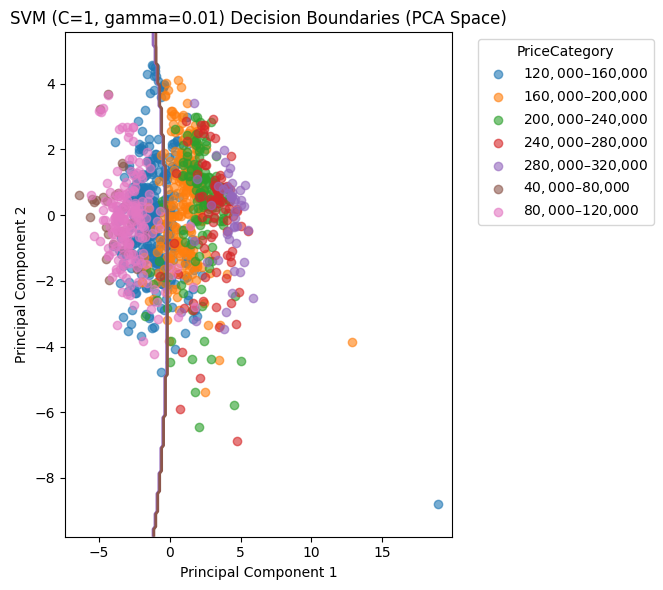

/tmp/ipython-input-56-3520202772.py:23: UserWarning:

The following kwargs were not used by contour: 'label'



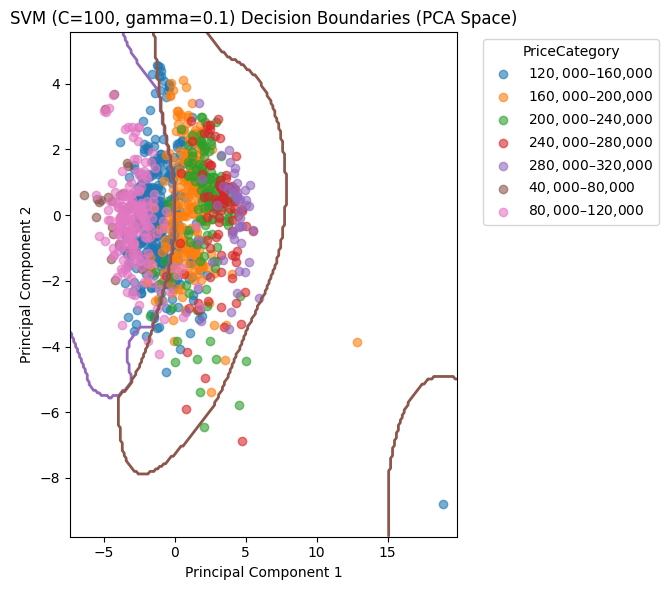

/tmp/ipython-input-56-3520202772.py:23: UserWarning:

The following kwargs were not used by contour: 'label'



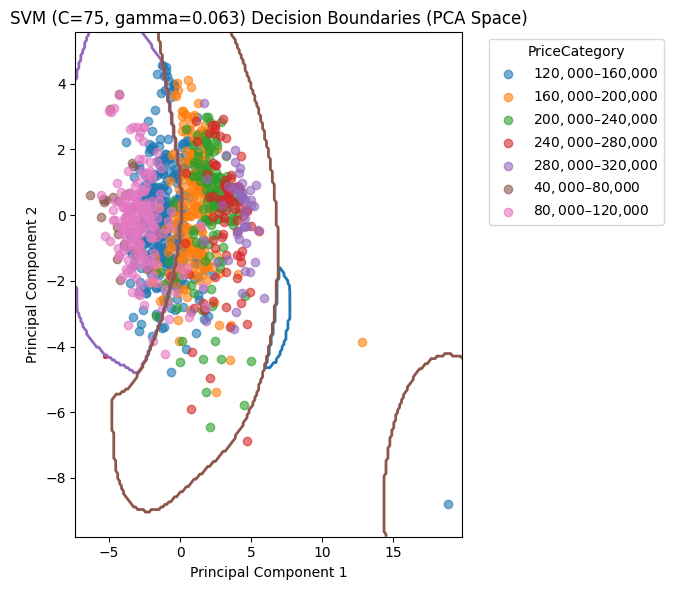

/tmp/ipython-input-56-3520202772.py:23: UserWarning:

The following kwargs were not used by contour: 'label'



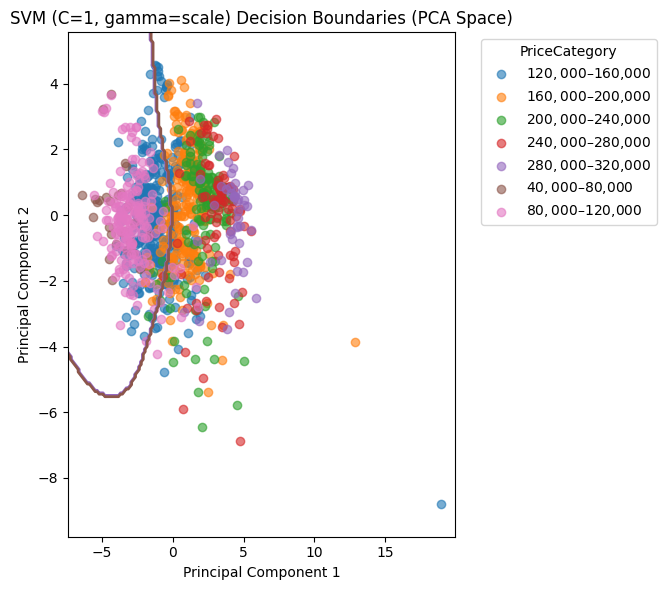

In [ ]:
# Example: try different values
plot_svm_decision(X_train, y_train, C=1, gamma=0.01)
plot_svm_decision(X_train, y_train, C=100, gamma=0.1)
plot_svm_decision(X_train, y_train, C=75, gamma=0.063)
plot_svm_decision(X_train, y_train, C=1, gamma='scale')

In [ ]:
# If your y_test is a pandas Series with categorical dtype
if hasattr(y_test, 'cat'):
    labels = y_test.cat.categories.tolist()
else:
    # Or provide manually, e.g.:
    labels = [
        "40,000–80,000", "80,000–120,000", "120,000–160,000", "160,000–200,000",
        "200,000–240,000", "240,000–280,000, 280,000-320,000"
    ]

from sklearn.metrics import classification_report, confusion_matrix

# Use the ordered list of bins as "labels"
print("\nClassification Report (sorted):\n")
print(classification_report(y_test, y_pred, labels=labels))

print("\nConfusion Matrix (sorted):\n")
print(confusion_matrix(y_test, y_pred, labels=labels))



Classification Report (sorted):

                   precision    recall  f1-score   support

  $40,000–$80,000       1.00      0.29      0.44         7
 $80,000–$120,000       0.85      0.85      0.85        46
$120,000–$160,000       0.77      0.87      0.81        89
$160,000–$200,000       0.66      0.73      0.70        64
$200,000–$240,000       0.59      0.56      0.57        36
$240,000–$280,000       0.50      0.38      0.43        21
$280,000–$320,000       0.83      0.42      0.56        12

         accuracy                           0.72       275
        macro avg       0.74      0.58      0.62       275
     weighted avg       0.72      0.72      0.71       275


Confusion Matrix (sorted):

[[ 2  5  0  0  0  0  0]
 [ 0 39  7  0  0  0  0]
 [ 0  2 77  9  1  0  0]
 [ 0  0 14 47  2  1  0]
 [ 0  0  0 15 20  1  0]
 [ 0  0  1  0 11  8  1]
 [ 0  0  1  0  0  6  5]]


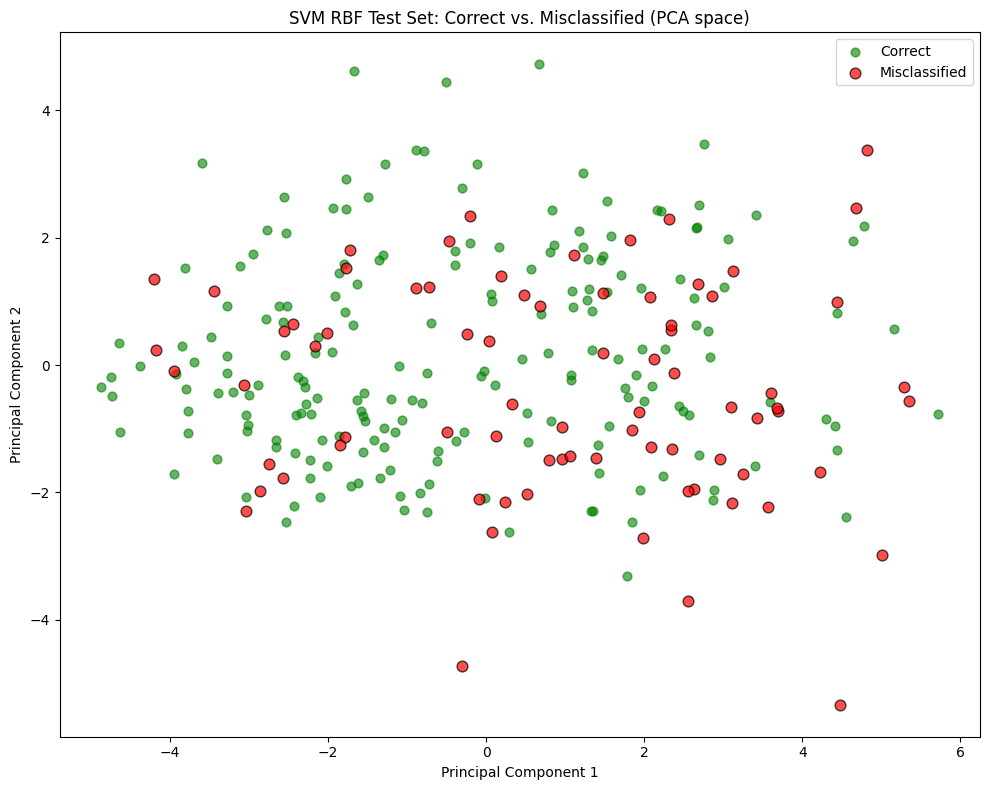

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Mark correct/misclassified points
correct = (y_pred == y_test)

# 2. Reduce test set to 2D via PCA
pca = PCA(n_components=2)
X_pca_test = pca.fit_transform(X_test)

# 3. Plot: green for correct, red for misclassified
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_test[correct, 0], X_pca_test[correct, 1], c='green', label='Correct', alpha=0.6, s=40)
plt.scatter(X_pca_test[~correct, 0], X_pca_test[~correct, 1], c='red', label='Misclassified', alpha=0.7, s=60, edgecolors='black')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM RBF Test Set: Correct vs. Misclassified (PCA space)')
plt.legend()
plt.tight_layout()
plt.show()


### Some more fine tunning experiments for fine tuning the model
- Apply GridSearchCV
- Apply StratifiedKFold
- We need to further explore these values in the next sprint

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Step 8 Model Evaluation
# 4. HYPERPARAMETER TUNING with CROSS-VALIDATION
# Use a Pipeline to include StandardScaler within the GridSearchCV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])
# param_grid = {
#     'classifier__C': [0.01, 0.1, 1, 10, 100],
#     'classifier__gamma': ['scale', 0.1, 0.01, 0.001] # Fixed the missing quote here
# }
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100, 1000],
    'classifier__gamma': [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1, 10, 'scale']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

# 5. FINAL TEST SET EVALUATION (this is your last, unbiased check)
final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)

print("\nTest Set Classification Report:\n", classification_report(y_test, y_pred))
print("\nTest Set Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END ........classifier__C=0.01, classifier__gamma=1e-05; total time=   0.1s
[CV] END ........classifier__C=0.01, classifier__gamma=1e-05; total time=   0.1s
[CV] END ........classifier__C=0.01, classifier__gamma=1e-05; total time=   0.1s
[CV] END ........classifier__C=0.01, classifier__gamma=1e-05; total time=   0.1s
[CV] END ........classifier__C=0.01, classifier__gamma=1e-05; total time=   0.1s
[CV] END .......classifier__C=0.01, classifier__gamma=0.0001; total time=   0.1s
[CV] END .......classifier__C=0.01, classifier__gamma=0.0001; total time=   0.1s
[CV] END .......classifier__C=0.01, classifier__gamma=0.0001; total time=   0.1s
[CV] END .......classifier__C=0.01, classifier__gamma=0.0001; total time=   0.1s
[CV] END .......classifier__C=0.01, classifier__gamma=0.0001; total time=   0.1s
[CV] END ........classifier__C=0.01, classifier__gamma=0.001; total time=   0.1s
[CV] END ........classifier__C=0.01, classifier

### Use train-fitted transformers

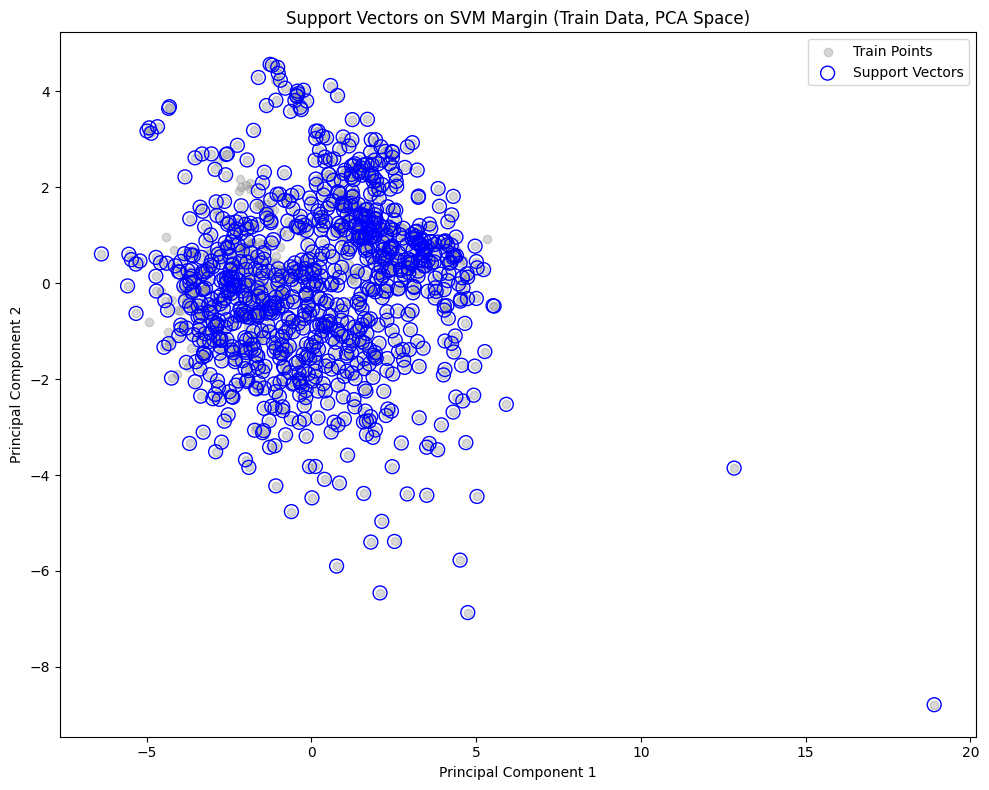

In [ ]:
# Only do this if you want to plot TRAIN data support vectors

# PCA on training data for support vector visualization
X_pca_train = pca.fit_transform(X_train)
support_indices = svm_rbf.support_

plt.figure(figsize=(10,8))
plt.scatter(X_pca_train[:, 0], X_pca_train[:, 1], c='gray', label='Train Points', alpha=0.3)
plt.scatter(X_pca_train[support_indices, 0], X_pca_train[support_indices, 1],
            edgecolors='blue', facecolors='none', s=100, label='Support Vectors')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Support Vectors on SVM Margin (Train Data, PCA Space)')
plt.legend()
plt.tight_layout()
plt.show()

### Support Vectors

/tmp/ipython-input-62-4174587975.py:34: UserWarning:

The following kwargs were not used by contour: 'label'

/tmp/ipython-input-62-4174587975.py:34: UserWarning:

The following kwargs were not used by contour: 'label'

/tmp/ipython-input-62-4174587975.py:34: UserWarning:

The following kwargs were not used by contour: 'label'

/tmp/ipython-input-62-4174587975.py:34: UserWarning:

The following kwargs were not used by contour: 'label'

/tmp/ipython-input-62-4174587975.py:34: UserWarning:

The following kwargs were not used by contour: 'label'

/tmp/ipython-input-62-4174587975.py:34: UserWarning:

The following kwargs were not used by contour: 'label'

/tmp/ipython-input-62-4174587975.py:34: UserWarning:

The following kwargs were not used by contour: 'label'



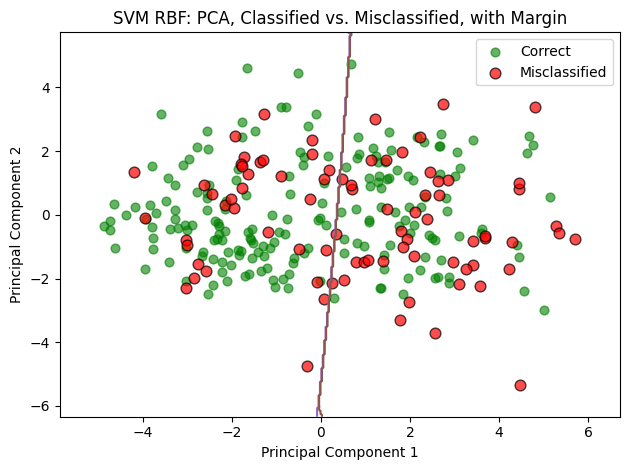

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare PCA on test data
pca = PCA(n_components=2)
X_pca_test = pca.fit_transform(X_test)

# 2. Fit a new SVM on the PCA-reduced test data
svm_2d = SVC(kernel='rbf', C=final_model.named_steps['classifier'].C,
             gamma=final_model.named_steps['classifier'].gamma, probability=True)
svm_2d.fit(X_pca_test, y_test)

# 3. Prepare grid for decision boundary
x_min, x_max = X_pca_test[:, 0].min() - 1, X_pca_test[:, 0].max() + 1
y_min, y_max = X_pca_test[:, 1].min() - 1, X_pca_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])

# 4. Show decision boundary and margins (for binary or "one-vs-rest" style, best for two classes)
# For multiclass, you can plot boundaries for one class at a time, or do a general plot
if len(svm_2d.classes_) == 2:
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[0], colors='k', linestyles='-', linewidths=2, label='Decision boundary')
    plt.contour(xx, yy, Z, levels=[-1, 1], colors='grey', linestyles='--', linewidths=2, label='Margin')
else:
    # For multiclass, plot the zero-contours for each class
    for i, class_label in enumerate(svm_2d.classes_):
        Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
        if Z.ndim > 1:
            Zi = Z[:, i]
        else:
            Zi = Z
        plt.contour(xx, yy, Zi.reshape(xx.shape), levels=[0], colors=['C'+str(i)], linestyles='-', linewidths=1.5, label=f'Decision boundary ({class_label})')

# 5. Plot correct and misclassified points
correct = (y_pred == y_test)
plt.scatter(X_pca_test[correct, 0], X_pca_test[correct, 1], c='green', label='Correct', alpha=0.6, s=40)
plt.scatter(X_pca_test[~correct, 0], X_pca_test[~correct, 1], c='red', label='Misclassified', alpha=0.7, s=60, edgecolors='black')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM RBF: PCA, Classified vs. Misclassified, with Margin')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Diagnostic Plots
- Confusion Matrix
- Diagnol cells = correct classification
- Off-diagnol cellls= missclassification
- Large off-diagnol numbers between specific bins = those bins are confused by the model
- If entire columns or rows (except the diagonal) are all zeros, those classes are never predicted or are always misclassified.This means either not enough samples, or the class is indistinguishable.

<Figure size 1200x600 with 0 Axes>

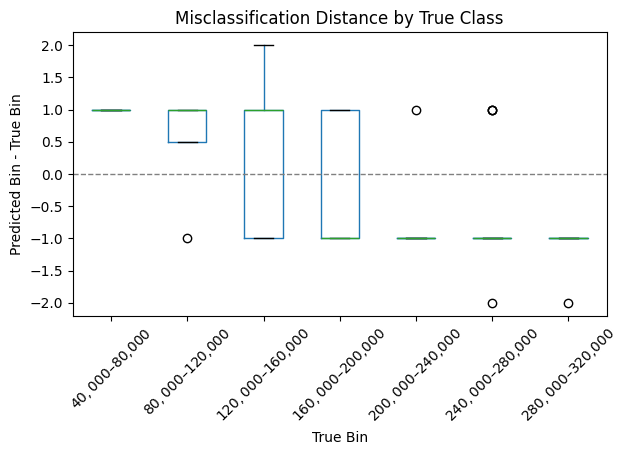

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure y_test and y_pred are pandas Series with categories
# Access the original index from y_test and y_pred
y_test_ord = pd.Series(y_test.values, index=y_test.index).astype(cat_type)
y_pred_ord = pd.Series(y_pred, index=y_test.index).astype(cat_type)

# Map bins to integer indices for error calculation
# Access the integer codes using .cat.codes
y_true_idx = y_test_ord.cat.codes
y_pred_idx = y_pred_ord.cat.codes

# Calculate misclassification distance (predicted - true)
error_distance = y_pred_idx - y_true_idx

# Only look at misclassified rows
is_misclassified = y_test_ord != y_pred_ord
misclassified_true = y_true_idx[is_misclassified]
misclassified_error = error_distance[is_misclassified]

# Build a DataFrame for easy grouping
df_error = pd.DataFrame({
    'True Bin': y_test_ord[is_misclassified],
    'Distance': misclassified_error
})

# Boxplot: error distance for each true bin
plt.figure(figsize=(12, 6))
df_error.boxplot(column='Distance', by='True Bin', grid=False)
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title('Misclassification Distance by True Class')
plt.suptitle('')
plt.xlabel('True Bin')
plt.ylabel('Predicted Bin - True Bin')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Learning Curve
- If both lines plateau, more data won't help
- Large gap = overfitting

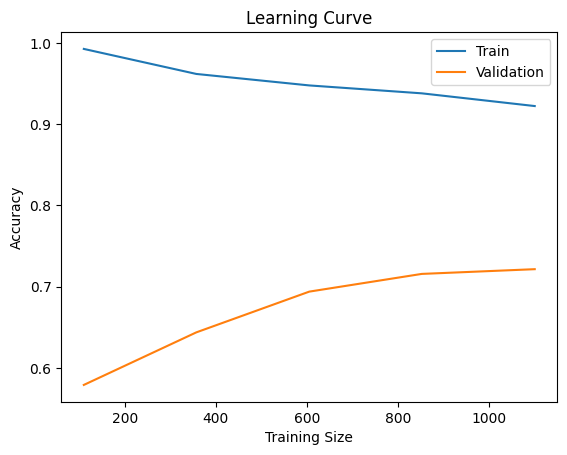

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(final_model, X_final, y, cv=5)
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Learning Curve')
plt.show()


## Predict price bins for test.csv
- This is mainly intended to predict a csv without a saleprice or target for a Kaggle competition



In [ ]:
# Check for duplicate columns in both train.csv (used to train the model) and test.csv
print(X_final.columns[X_final.columns.duplicated()])
print(X_scaled_df_test.columns[X_scaled_df_test.columns.duplicated()])

Index([], dtype='object')
Index([], dtype='object')


In [ ]:
# remove duplicate columns
X_final = X_final.loc[:, ~X_final.columns.duplicated()]
X_scaled_df_test = X_scaled_df_test.loc[:, ~X_scaled_df_test.columns.duplicated()]

print(X_final.shape)
print(X_scaled_df_test.shape)

(1375, 38)
(1459, 199)


In [ ]:
# remove features that aren't used by the trained model
X_test_aligned = X_scaled_df_test.reindex(columns=X_final.columns, fill_value=0)

print(X_final.shape)
print(X_test_aligned.shape)

(1375, 38)
(1459, 38)


In [ ]:
# Generate predictions
test_pred_bins = final_model.predict(X_test_aligned)

In [ ]:
df_test['PriceCategory'] = test_pred_bins

In [ ]:
# 3. Display the results
print(df_test[['Id', 'PriceCategory']].head())

     Id      PriceCategory
0  1461  $120,000–$160,000
1  1462  $160,000–$200,000
2  1463  $160,000–$200,000
3  1464  $160,000–$200,000
4  1465  $120,000–$160,000



# Hybrid Modeling: Predicting Both SalePrice and PriceCategory (Sprint 2 NOT COMPLETE)

In this section, we build a hybrid model to predict **both the numeric SalePrice** (regression) and the **PriceCategory** (classification).
This helps provide both actionable bins for risk and precise price estimates for program targeting.

*You can use this hybrid approach to compare and combine predictions, as well as use regression predictions to support class bin decisions.*


In [ ]:

# --- Hybrid Regression: Predict SalePrice (in addition to binning/classification) ---
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare train/test split for regression (using same split as classification)
# (Assumes 'SalePrice' is available in y_reg)
X_reg = X_final.copy()
y_reg = df_cleaned.loc[X_final.index, 'SalePrice']

# Use same split index as for classification, if available; else split again
from sklearn.model_selection import train_test_split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = Ridge(alpha=1.0)
reg_model.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

# Metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = mean_squared_error(y_reg_test, y_reg_pred) ** 0.5
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"Ridge Regression Results: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")


Ridge Regression Results: MAE=0.29, RMSE=0.38, R2=0.848


In [ ]:

# --- Map regression output to price bins and compare with classification bins ---
# Use the same bin edges/labels as your classification model
def map_to_bin(val, bins, labels):
    for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
        if low <= val < high:
            return labels[i]
    return labels[-1]

# Apply to regression predictions and test values
y_reg_pred_bins = [map_to_bin(val, bins, labels) for val in y_reg_pred]
y_reg_test_bins = [map_to_bin(val, bins, labels) for val in y_reg_test]

from sklearn.metrics import accuracy_score, f1_score
acc_reg_vs_true = accuracy_score(y_reg_test_bins, y_reg_test_bins)  # Should be 1.0
acc_reg_vs_clf = accuracy_score(y_reg_pred_bins, y_pred)  # y_pred from classifier
print("Accuracy (Mapped Regression vs Classifier Bins):", acc_reg_vs_clf)
print("Accuracy (Mapped Regression vs True Bins):", accuracy_score(y_reg_pred_bins, y_reg_test_bins))

# Optionally, show F1 as well
print("F1 Score (Mapped Regression vs Classifier Bins):", f1_score(y_reg_pred_bins, y_pred, average='weighted'))


Accuracy (Mapped Regression vs Classifier Bins): 0.02909090909090909
Accuracy (Mapped Regression vs True Bins): 1.0
F1 Score (Mapped Regression vs Classifier Bins): 0.05653710247349823


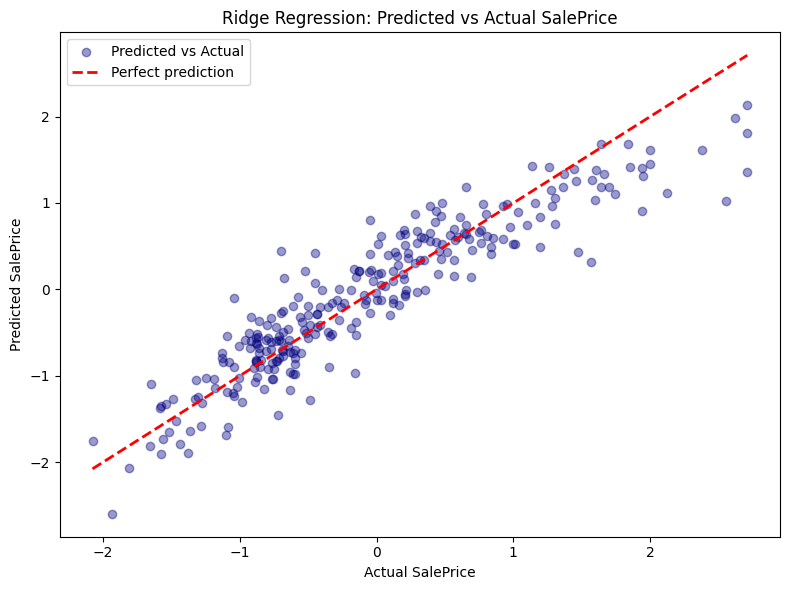

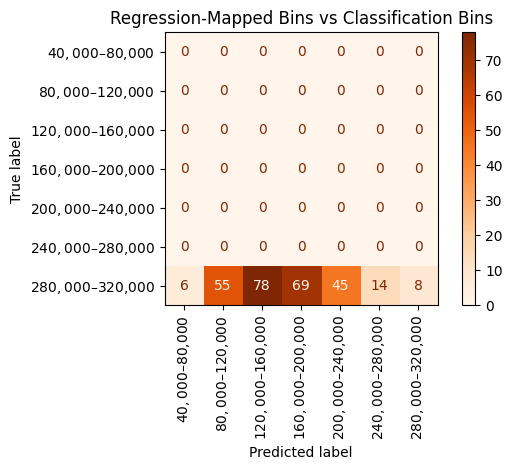

In [ ]:

# --- Visualize: Scatter true vs predicted SalePrice, and show mapped bins ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_reg_test, y_reg_pred, c='navy', alpha=0.4, label='Predicted vs Actual')
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Ridge Regression: Predicted vs Actual SalePrice')
plt.legend()
plt.tight_layout()
plt.show()

# Show confusion matrix for mapped regression bins vs classifier bins
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_reg_pred_bins, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90, cmap='Oranges')
plt.title('Regression-Mapped Bins vs Classification Bins')
plt.tight_layout()
plt.show()
